<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/logistic_Regrations_handson_1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
data=pd.read_csv('/content/bank-additional-full-1.csv',sep=';')

In [ ]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.shape

(41199, 21)

In [ ]:
data.dtypes

,0
age,float64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [ ]:
data.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [ ]:
data.duplicated().sum()

np.int64(15)

**age:** Age of the customer/client


**job:** Type of job


**married:** Marital Status of customer


**education:** Education level.


**default:** The person has a history of default credit or loan (Bad credit).


**housing:** Has housing loan


**loan:** Has personal loan


**contact** Contact communication type


**month:** Last contact month


**day_of_week:** Last contact day of the week (Mon,Tue..)


**duration:** Last contact duration in seconds.


**campaign:** Number of contacts perfomed during this campagin.


**pdays:** Days since the client was last contacted (999 means never contacted before.)


**previous:** Number of contacts before this campaign.


**poutcome:** Outcome of the previous marketing campaign.


**emp.var.rate:** Employement variation rate (Employement rate)


**cons.price.idx:** Consumer price index, an indicator that measures average price changes for goods and services bought by households.


**cons.conf.idx:** Consumer confidence index, it measures how confident/satisfied/optimistic people feel about the economy.


**euribor3m:** Euribor 3month rate. It is the interest rate at which European banks lend money  to each other for 3 months.


**nr.employed:** Number of employed people.


**y:** Has the client subscribed/took the fixed deposit/term deposit.

In [ ]:
for column in data.columns:
  if data[column].dtype =="object":
    data[column] = data[column].fillna(data[column].mode()[0])

  elif data[column].dtype =="float64":
    data[column] =data[column].fillna(data[column].mean())

In [ ]:
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
data.duplicated().sum()

np.int64(16)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

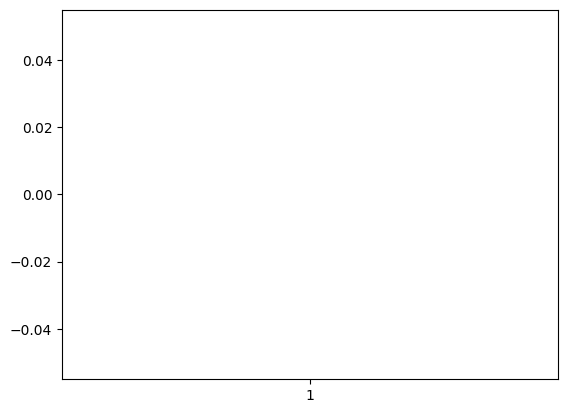

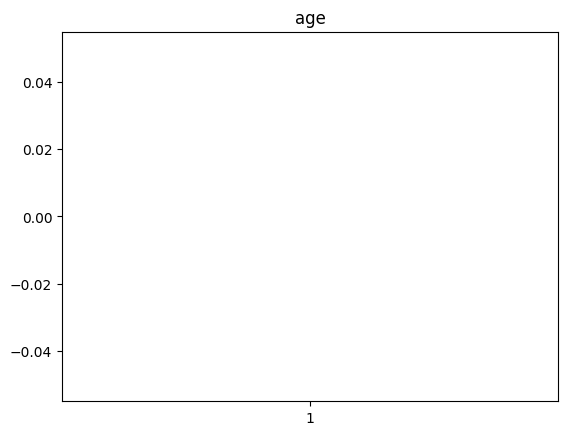

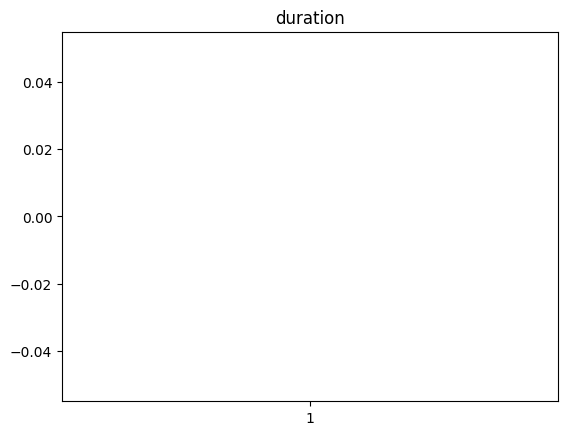

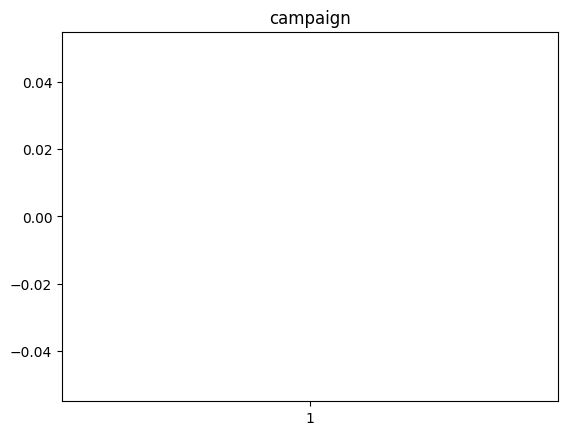

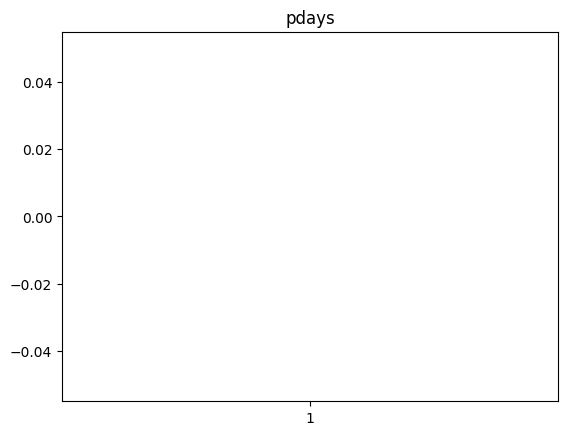

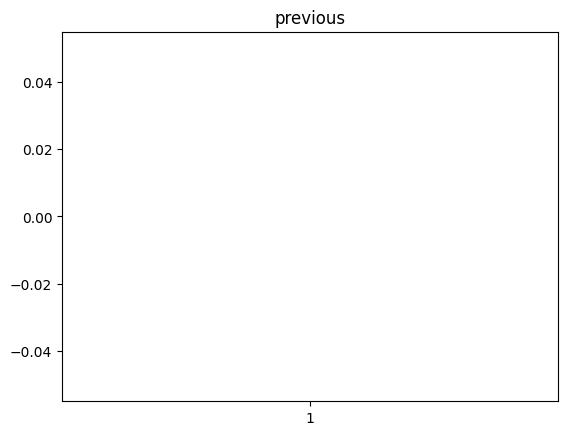

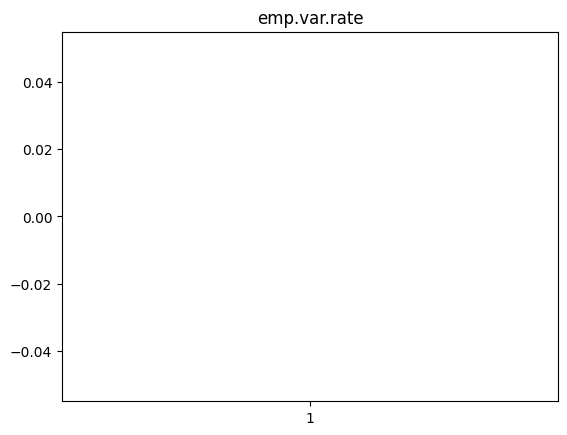

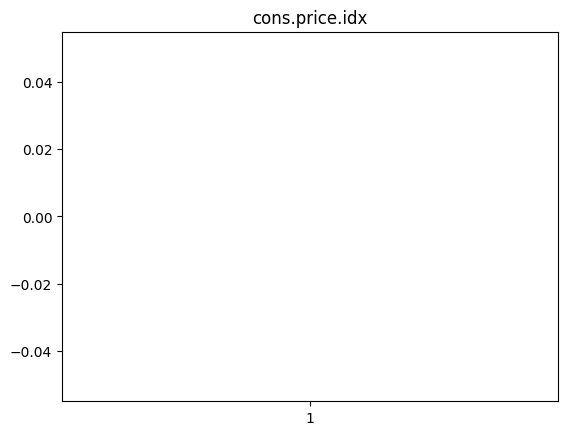

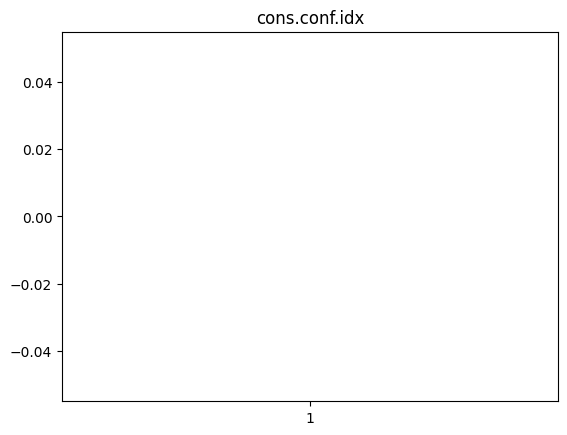

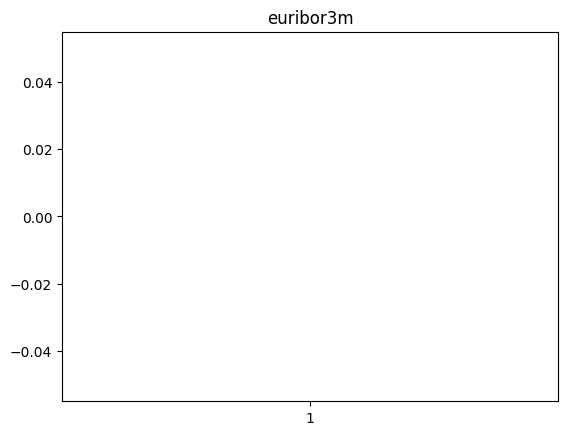

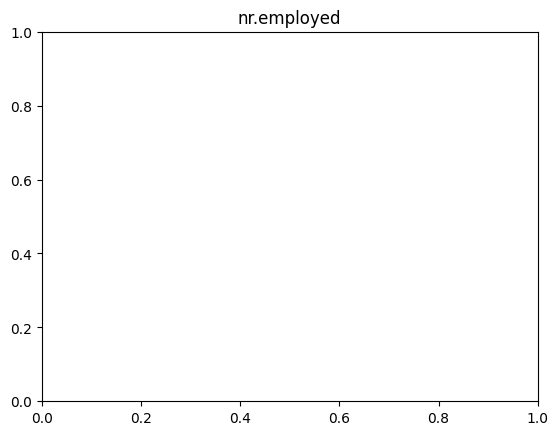

In [ ]:
for i in data.columns:
  if data[i].dtype !="object":
    plt.boxplot(data[i])
    plt.show()
    plt.title(i)

In [ ]:
outliers=['duration','campaign','cons.conf.idx']

In [ ]:
for i in outliers:
  Q1=data[i].quantile(0.25)
  Q3=data[i].quantile(0.75)
  IQR=Q3-Q1
  ub=Q3+1.5*IQR
  lb=Q1-1.5*IQR
  data = data[(data[i]>=lb) & (data[i]<=ub)]

In [ ]:
data.shape

(0, 21)

In [ ]:
# Label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             0 non-null      float64
 1   job             0 non-null      object 
 2   marital         0 non-null      object 
 3   education       0 non-null      object 
 4   default         0 non-null      object 
 5   housing         0 non-null      object 
 6   loan            0 non-null      object 
 7   contact         0 non-null      object 
 8   month           0 non-null      object 
 9   day_of_week     0 non-null      object 
 10  duration        0 non-null      float64
 11  campaign        0 non-null      float64
 12  pdays           0 non-null      float64
 13  previous        0 non-null      float64
 14  poutcome        0 non-null      object 
 15  emp.var.rate    0 non-null      float64
 16  cons.price.idx  0 non-null      float64
 17  cons.conf.idx   0 non-null      float64
 18  euribor

In [ ]:
#model bulding
